# **The 6-step Data Quality Method**
## https://github.com/royruddle/6-step-data-quality-method

This is the notebook that is used in the YouTube video about **Step 3** of the method (https://www.youtube.com/watch?v=uHSxjYqwY_Q), and shows how to use the vizdataquality package to investigate data quality.

The 6 steps are:
1. Is anything obviously wrong?
2. Watch out for special values
3. Is any data missing?
4. Check each variable
5. Check combinations of variables
6. Profile the cleaned data

## **Step 3: Is any data missing (is it safe to proceed or do you need more data)?**

## Includes: vizdataquality and other libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from vizdataquality import calculate as vdqc, plot as vdqp
from vizdataquality import missing_data_functions as mdf, missing_data_plots as mdp

### Tabular data

This example uses a dataset about potholes in roads (https://datamillnorth.org/dataset/historic-potholes-data-e7ylx), (c) Leeds City Council, 2019. The data is licensed under the terms of the Open Government Licence.

In [2]:
folder = '../../examples'
input_filename = os.path.join(folder, 'lcc_pothole_reports_data_mill_Oct%202025.csv')

# Read the dataset, but only treat empty cells as missing values
df = pd.read_csv(input_filename, encoding='ascii', na_values='', keep_default_na=False, low_memory=False)
num_rows = len(df)

#### Calculate the number of missing values in each column

In [3]:
column_stats = vdqc.calc(df, {'Missing values': True})

#### Matplotlib bar chart

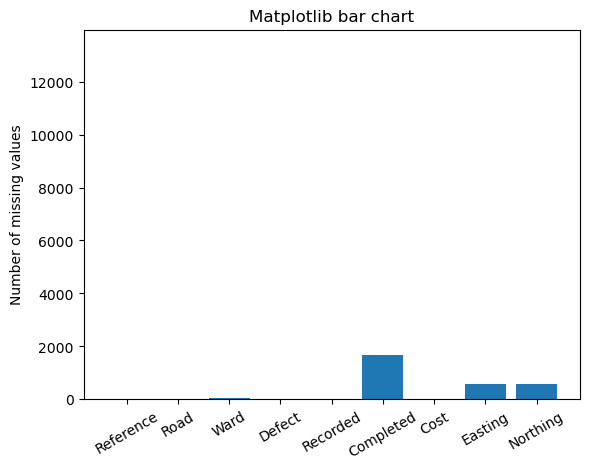

In [4]:
plt.bar(column_stats.index, column_stats['Number of missing values'].values)
plt.xticks(rotation=30)
plt.ylabel('Number of missing values')
# Y max = number of rows (see at a glance the proportion of missing values)
plt.ylim(0, len(df))
plt.title('Matplotlib bar chart')
plt.show()

#### vizdataquality bar chart

By using perceptual discontinuity, we ensure all of the bars are visible

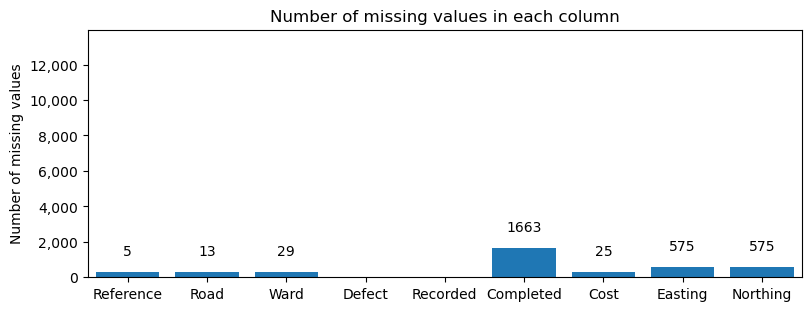

In [5]:
# A dictionary of keyword arguments that are passed to the Matplotlib Figure object
fig_kw = {'size_inches': (8, 3), 'constrained_layout': True}
# A dictionary of keyword arguments that are passed to the Matplotlib Axes object
ax_kw = {'title': 'Number of missing values in each column', 'xlabel': '', 'ylim': (0, num_rows)}
# The perceptual_threshold ensures that every bar is visible
vdqp.scalar_bar(column_stats['Number of missing values'], perceptual_threshold=0.02, datalabels=True, fig_kw=fig_kw, ax_kw=ax_kw)

#### Visualize the combinations of missing values

In [6]:
# Calculate the combinations
num_missing, intersection_id_to_columns, intersection_id_to_records = mdf.get_intersections_from_dataframe(df)
intersection_cardinality = mdf.get_intersection_cardinality(intersection_id_to_records)

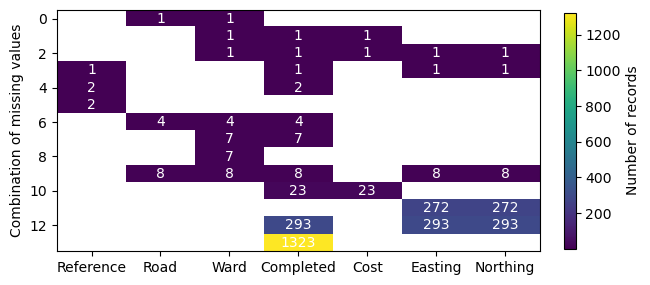

In [7]:
dftmp = mdf.get_intersection_heatmap_data(intersection_id_to_columns, intersection_cardinality)
# Sort the heatmap so the combinations are in ascending cardinality order
dftmp['_max'] = dftmp.max(axis=1)
df_heatmap = dftmp.sort_values(by='_max').drop(columns='_max')
fig_kw = { 'constrained_layout': True}
ax_kw = {'ylabel': 'Combination of missing values'}
cbar_kw = {'label': 'Number of records', 'shrink': 0.5}
mdp.plot_intersection_heatmap(df_heatmap, transpose=False, datalabels=True, fig_kw=fig_kw, ax_kw=ax_kw, cbar_kw=cbar_kw, aspect=0.25)

### Longitudinal coverage

This example uses a dataset about water meter readings (https://datamillnorth.org/dataset/domestic-consumption-monitor-monthly-meter-readings-e51j7), (c) Leeds City Council, 2026. The data is licensed under the terms of the Open Government Licence.

In [8]:
folder = '../../examples'
input_filename = os.path.join(folder, 'Domestic%20Consumption%20Monitor%20monthly%20meter%20readings%202010-2015.csv')

# Read the dataset, only treating empty cells as missing values
df = pd.read_csv(input_filename, encoding='ascii', na_values='', keep_default_na=False, low_memory=False)
# Treat the zero meter readings as missing (see Step 2)
df = df.replace(0, np.nan)

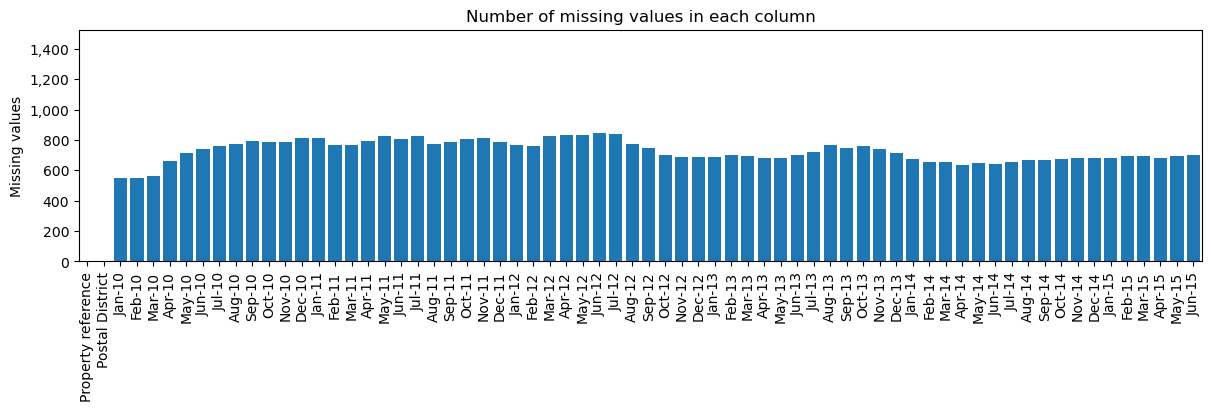

In [9]:
# Calculate the number of missing values in each column
column_stats = vdqc.calc(df, {'Missing values': True})

fig_kw = {'size_inches': (12, 4), 'constrained_layout': True}
ax_kw = {'title': 'Number of missing values in each column', 'xlabel': '', 'ylabel': 'Missing values', 'ylim': (0, len(df))}
vdqp.scalar_bar(column_stats['Number of missing values'], xlabels_rotate=90, fig_kw=fig_kw, ax_kw=ax_kw)

#### How complete are the rows?

NB: This bar chart also uses perceptual discontinuity to ensure all of the bars are visible

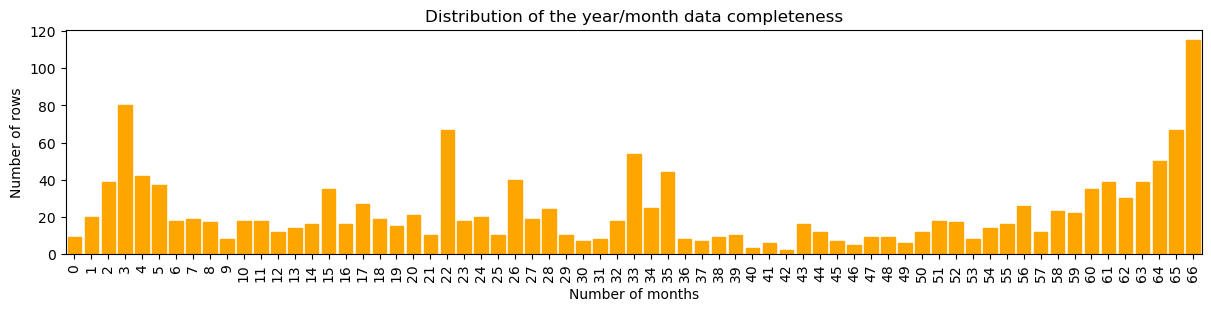

In [10]:
# Count the number and distribution of year/month values in each row
num_values_in_rows = df[df.columns[2:]].notnull().sum(axis=1).value_counts().sort_index()

fig_kw = {'size_inches': (12, 3), 'constrained_layout': True}
ax_kw = {'title': 'Distribution of the year/month data completeness', 'xlabel': 'Number of months', 'ylabel': 'Number of rows'}
bar_colour = {'color': 'orange', 'edgecolor': 'orange'}
vdqp.scalar_bar(num_values_in_rows, xlabels_rotate=90, fig_kw=fig_kw, ax_kw=ax_kw, **bar_colour)